# <u>LIMPIEZA DEL DATASET:</u>

In [1]:
import numpy as np
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
df = pd.read_csv('../data/cars.csv')

## <u>TIPADO DE DATOS:</u>

In [3]:
df.dtypes

manufacturer            object
model                   object
year                     int64
mileage                float64
engine                  object
transmission            object
drivetrain              object
fuel_type               object
mpg                     object
exterior_color          object
interior_color          object
accidents_or_damage    float64
one_owner              float64
personal_use_only      float64
seller_name             object
seller_rating          float64
driver_rating          float64
driver_reviews_num     float64
price_drop             float64
price                  float64
dtype: object

In [4]:
df.dtypes.to_dict()

{'manufacturer': dtype('O'),
 'model': dtype('O'),
 'year': dtype('int64'),
 'mileage': dtype('float64'),
 'engine': dtype('O'),
 'transmission': dtype('O'),
 'drivetrain': dtype('O'),
 'fuel_type': dtype('O'),
 'mpg': dtype('O'),
 'exterior_color': dtype('O'),
 'interior_color': dtype('O'),
 'accidents_or_damage': dtype('float64'),
 'one_owner': dtype('float64'),
 'personal_use_only': dtype('float64'),
 'seller_name': dtype('O'),
 'seller_rating': dtype('float64'),
 'driver_rating': dtype('float64'),
 'driver_reviews_num': dtype('float64'),
 'price_drop': dtype('float64'),
 'price': dtype('float64')}

### <u>'seller_name to price'</u>

- La columna `seller_name` la ponemos como tipo **string**, ya que contiene el nombre del vendedor en formato texto.
- La columna `seller_rating` la ponemos como tipo **float64**, porque representa una valoración numérica con decimales.
- La columna `driver_rating` la ponemos como tipo **float64**, ya que también es una valoración numérica con decimales.
- La columna `driver_reviews_num` la ponemos como tipo **Int64**, porque almacena el número de reseñas y es un valor entero, pero queremos permitir valores nulos (`NaN`).
- La columna `price_drop` la ponemos como tipo **float64**, dado que representa una variación de precio (rebaja) que incluye decimales.
- La columna `price` la ponemos como tipo **Int64**, porque el precio del vehículo se maneja como valor entero, y así mantenemos compatibilidad con valores nulos si los hubiera.


In [5]:
df = df.astype({
    'seller_name': 'string',
    'seller_rating': 'float64',
    'driver_rating': 'float64',
    'driver_reviews_num': 'Int64',
    'price_drop': 'float64',
    'price': 'Int64'
})

## <u>VALORES ERRÓNEOS:</u>

In [6]:
pd.isnull(df).sum()

manufacturer                0
model                       0
year                        0
mileage                   506
engine                  15050
transmission             9904
drivetrain              21562
fuel_type               22927
mpg                    142071
exterior_color           8859
interior_color          56975
accidents_or_damage     24212
one_owner               31483
personal_use_only       24852
seller_name              8593
seller_rating          213973
driver_rating           31632
driver_reviews_num          0
price_drop             351979
price                       0
dtype: int64

In [7]:
pd.isnull(df[[x for x in df.columns[pd.isnull(df).any()].tolist()]]).sum()

mileage                   506
engine                  15050
transmission             9904
drivetrain              21562
fuel_type               22927
mpg                    142071
exterior_color           8859
interior_color          56975
accidents_or_damage     24212
one_owner               31483
personal_use_only       24852
seller_name              8593
seller_rating          213973
driver_rating           31632
price_drop             351979
dtype: int64

In [8]:
df[df.isna().any(axis=1)][[x for x in df.columns[pd.isnull(df).any()]]]

,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,price_drop
0,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,300.0
1,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,NaN
3,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,675.0
4,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,300.0
6,57212.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Silver,Ebony,0.0,1.0,1.0,Ohio Car Mart,NaN,4.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762082,6302.0,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,All-wheel Drive,Gasoline,25-33,Birch Light Metallic,Charcoal,0.0,1.0,0.0,Scott Volvo Cars Allentown,NaN,4.2,NaN
762083,13972.0,2.0L I4 16V GDI DOHC,8-Speed Automatic,All-wheel Drive,Gasoline,21-32,White,NaN,0.0,1.0,0.0,Simmons-Rockwell Hyundai,NaN,4.9,NaN
762087,72900.0,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,A/T,Front-wheel Drive,Gasoline,NaN,Red,Beige,NaN,NaN,NaN,<NA>,NaN,4.5,NaN
762088,92000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,Front-wheel Drive,Gasoline,21-30,Ice White,Soft Beige,0.0,0.0,1.0,Dapper Car Sales,NaN,4.8,300.0


### <u>'mileage'</u>
##### Hemos imputado los valores faltantes de mileage usando una estrategia escalonada, rellenando primero por manufacturer + model + year y después por medianas de fabricante y globales. Así hemos obtenido un kilometraje coherente con la edad y el tipo de coche, evitando perder datos valiosos.

In [9]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    df['mileage'] = (
        df.groupby(['manufacturer', 'model', 'year'])['mileage']
          .transform(lambda x: x.fillna(x.median()))
    )

#Estamos rellenando los valores nulos con la mediana teniendo en cuenta las columnas: 'manufacturer','model','year'.

In [10]:
df['mileage'] = df['mileage'].fillna(df['mileage'].median())
#Tras rellenar los ausentes de 'mileage' con la mediana de 'manufacturer','model','year', nos siguen quedando 20 valores nulos. A estos últimos le hemos rellenado los valores teniendo en cuenta la mediana de 'mileage'.

In [11]:
df['mileage'].describe()

count    7.620910e+05
mean     5.577397e+04
std      4.356073e+04
min      0.000000e+00
25%      2.327400e+04
50%      4.559000e+04
75%      7.836300e+04
max      1.119067e+06
Name: mileage, dtype: float64

### <u>'engine'</u>
##### Hemos limpiado la columna engine dividiéndola en tres variables numéricas y categóricas: engine_liters, engine_cylinders y engine_type. Después hemos imputado los valores faltantes de litros y cilindros usando medianas por grupos coherentes (manufacturer + model + year + cylinders), quedando listas para ML

In [12]:
#Pasamos todos los valores de 'engine' a minúsculas.
df['engine_clean'] = df['engine'].str.lower()

In [13]:
#Extraemos la cilindrada (litros)
def extract_liters(x):
    if pd.isna(x):
        return None
    match = re.search(r'(\d\.\d|\d)\s*l', x)
    if match:
        return float(match.group(1))
    return None

df['engine_liters'] = df['engine_clean'].apply(extract_liters)

In [14]:
#Extraemos el número de cilindridos
def extract_cylinders(x):
    if pd.isna(x):
        return None
    match = re.search(r'(v|i|l)(\d)', x)
    if match:
        return int(match.group(2))
    return None

df['engine_cylinders'] = df['engine_clean'].apply(extract_cylinders)

In [15]:
#Extraemos el tipo de motor
def extract_engine_type(x):
    if pd.isna(x):
        return "unknown"
    if "turbo" in x or "t" in x:
        return "turbo"
    if "super" in x:
        return "supercharged"
    if "electric" in x:
        return "electric"
    if "hybrid" in x:
        return "hybrid"
    return "natural"

df['engine_type'] = df['engine_clean'].apply(extract_engine_type)

In [16]:
#Si engine es electric: 
#litros=0; 
#cilindros=0
#Si creamos estas 3 columnas para diferenciar realmente entre la cilindrada, el número de cilindros y el tipo de motor podemos eliminar posteriormente 'engine_clean':
df.drop(columns=['engine_clean'], inplace=True)

In [17]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    df['engine_liters'] = (
        df.groupby(['manufacturer', 'model'])['engine_liters']
          .transform(lambda x: x.fillna(x.median()))
    )
#A los missing values de la nueva columna 'engine_liters', le hemos imputado la mediana teniendo en cuenta las columnas 'manufacturer' y 'model'. 

In [18]:
df['engine_liters'] = df.groupby(['manufacturer'])['engine_liters'] \
                         .transform(lambda x: x.fillna(x.median()))
#Como nos siguen quedan valores nulos después de la imputación anterior, le hemos imputado de nuevo la mediana pero ahora teniendo solo en cuenta 'manufacturer'.

In [19]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    df['engine_cylinders'] = (
        df.groupby(['manufacturer', 'model'])['engine_cylinders']
          .transform(lambda x: x.fillna(x.median()))
    )

#A los missing values de la nueva columna 'engine_cylinders', le hemos imputado la mediana teniendo en cuenta las columnas 'manufacturer' y 'model'. 

In [20]:
df['engine_cylinders'] = df.groupby(['manufacturer'])['engine_cylinders'] \
                            .transform(lambda x: x.fillna(x.median()))
#Como nos siguen quedan valores nulos después de la imputación anterior, le hemos imputado de nuevo la mediana pero ahora teniendo solo en cuenta 'manufacturer'.

In [21]:
df.drop(columns=['engine'], inplace=True)

### <u>'transmission'</u>
##### Hemos clasificado y unificado todos los valores de transmission en automatic, manual y unknown, detectando variantes como A/T, CVT, Dual-Clutch, 8-speed, etc., y hemos eliminado los registros clasificados como “other” tras limpiar la columna correctamente.

In [22]:
df['transmission_clean'] = df['transmission'].astype(str).str.lower()

def simplify_transmission(x):
    if pd.isna(x) or x.strip() == "":
        return "unknown"
    
    # AUTOMÁTICAS
    if any(word in x for word in [
        "automatic",          
        "auto ", " auto",     
        "a/t", "at",
        "cvt", 
        "continuously variable", 
        "variable",
        "dct", 
        "dual", 
        "tiptronic", 
        "dsg",
        "shift",
        "8-speed", "8 speed", "8spd",
        "7-speed", "7 speed", "7spd",
        "9-speed", "9 speed", "9spd",
        "10-speed", "10 speed", "10spd"
    ]):
        return "automatic"
    
    # MANUALES
    if any(word in x for word in [
        "manual",
        "m/t", "mt",
        "man ",
        "5-speed", "5 speed",
        "6-speed", "6 speed",
        "5spd", "6spd"
    ]):
        return "manual"
    
    return "other"

df['transmission_simple'] = df['transmission_clean'].apply(simplify_transmission)
df = df.drop(columns=['transmission_clean'])


In [23]:
df = df[df['transmission_simple'] != 'other']

In [24]:
df.drop(columns=['transmission'], inplace=True)

### <u>'drivetrain'</u>
##### Hemos normalizado todos los valores de drivetrain en las 4 categorías principales (Front-wheel, Rear-wheel, All-wheel, Four-wheel Drive), y eliminado los registros “unknown” y “other” para quedarnos solo con configuraciones de tracción válidas.

In [25]:
df['drivetrain'].value_counts()

drivetrain
Front-wheel Drive                                              239329
All-wheel Drive                                                229456
Four-wheel Drive                                               156065
Rear-wheel Drive                                                96430
FWD                                                              6405
AWD                                                              3579
4WD                                                              1908
RWD                                                              1736
Unknown                                                            91
Front-Wheel Drive                                                  82
All-Wheel Drive                                                    68
Front-Wheel Drive with Limited-Slip Differential                   44
Four-Wheel Drive with Locking and Limited-Slip Differential        42
All-Wheel Drive with Locking and Limited-Slip Differential         33
Four Whee

In [26]:
df['drivetrain_clean'] = df['drivetrain'].astype(str).str.lower()

def simplify_drivetrain(x):
    if pd.isna(x) or x.strip() == "" or x == "nan":
        return "unknown" 

    # FRONT-WHEEL DRIVE (FWD)
    if any(word in x for word in [
        "front-wheel", "front wheel", "fwd"
    ]):
        return "Front-wheel Drive"
    
    # REAR-WHEEL DRIVE (RWD)
    if any(word in x for word in [
        "rear-wheel", "rear wheel", "rwd"
    ]):
        return "Rear-wheel Drive"
    
    # ALL-WHEEL DRIVE (AWD)
    if any(word in x for word in [
        "all-wheel", "all wheel", "awd"
    ]):
        return "All-wheel Drive"
    
    # FOUR-WHEEL DRIVE (4WD)
    if any(word in x for word in [
        "four-wheel", "four wheel",
        "4wd", "4x4", "4 x 4"
    ]):
        return "Four-wheel Drive"
    
    return "other"

df['drivetrain_simple'] = df['drivetrain_clean'].apply(simplify_drivetrain)
df = df.drop(columns=['drivetrain_clean'])

In [27]:
df = df[df['drivetrain_simple'] != 'unknown']
df = df[df['drivetrain_simple'] != 'other']

In [28]:
df['drivetrain_simple'].value_counts()

drivetrain_simple
Front-wheel Drive    245877
All-wheel Drive      233166
Four-wheel Drive     158069
Rear-wheel Drive      98206
Name: count, dtype: int64

In [29]:
df.drop(columns=['drivetrain'], inplace=True)

### <u>'fuel_type'</u>
##### Con fuel_type hemos estandarizado todos los valores en 4 categorías limpias (Gasoline, Diesel, Hybrid, Electric),y¡ y hemos eliminado los registros “unknown” y “other” para quedarnos solo con combustibles válidos y consistentes para el modelo.

In [30]:
df['fuel_clean'] = df['fuel_type'].astype(str).str.lower()

def simplify_fuel(x):
    if pd.isna(x) or x.strip() == "" or x == "nan":
        return "unknown"
    
    # GASOLINE
    if any(word in x for word in [
        "gas", "gasoline", 
        "unleaded", "regular", "petrol"
    ]):
        return "Gasoline"
    
    # DIESEL
    if any(word in x for word in [
        "diesel", "tdi", "dci", "crdi"
    ]):
        return "Diesel"
    
    # HYBRID
    if any(word in x for word in [
        "hybrid", "phev", "plug-in"
    ]):
        return "Hybrid"
    
    # ELECTRIC
    if any(word in x for word in [
        "electric", "ev", "battery"
    ]):
        return "Electric"
    
    return "other"

df['fuel_simple'] = df['fuel_clean'].apply(simplify_fuel)
df = df.drop(columns=['fuel_clean'])

In [31]:
df['fuel_simple'].value_counts()

fuel_simple
Gasoline    635142
Hybrid       28720
Diesel       27726
other        19063
Electric     15974
unknown       8693
Name: count, dtype: int64

In [32]:
df = df[(df['fuel_simple'] != 'unknown') &
        (df['fuel_simple'] != 'other')]

### <u>'mpg'</u>
##### Hemos convertido los rangos de mpg en dos columnas numéricas (mpg_min y mpg_max), corrigiendo incluso los rangos invertidos. Después hemos imputado sus valores faltantes usando medianas por grupos coherentes (manufacturer + model + engine_cylinders).

In [33]:
def parse_ordered_mpg(x):
    if pd.isna(x):
        return (np.nan, np.nan)
    
    x = str(x).strip().replace("–", "-")
    
    # Si no hay rango (solo un valor)
    if "-" not in x:
        try:
            v = float(x)
            return (v, v)
        except:
            return (np.nan, np.nan)
    
    # Extraer números del rango
    nums = re.findall(r'\d+', x)
    
    if len(nums) == 2:
        a, b = float(nums[0]), float(nums[1])
        return (min(a, b), max(a, b))   # ← ORDENAMOS AQUÍ
    
    return (np.nan, np.nan)

df[['mpg_min', 'mpg_max']] = df['mpg'].apply(lambda x: pd.Series(parse_ordered_mpg(x)))

In [34]:
df[['mpg', 'mpg_min', 'mpg_max']].head(20)

,mpg,mpg_min,mpg_max
0,39-38,38.0,39.0
1,39-38,38.0,39.0
2,39-38,38.0,39.0
3,39-38,38.0,39.0
4,39-38,38.0,39.0
5,39-38,38.0,39.0
6,39-38,38.0,39.0
7,NaN,NaN,NaN
8,39-38,38.0,39.0
10,21-22,21.0,22.0


In [35]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    for col in ['mpg_min', 'mpg_max']:
        df[col] = (
            df.groupby(['manufacturer', 'model', 'engine_cylinders'])[col]
              .transform(lambda x: x.fillna(x.median()))
        )

#A los missing values de las nuevas columnas 'mpg_min y mpg_max', le hemos imputado la mediana teniendo en cuenta las columnas 'manufacturer', 'model' y 'engine_cylinders'.

In [36]:
for col in ['mpg_min', 'mpg_max']:
    df[col] = df.groupby('engine_cylinders')[col] \
                .transform(lambda x: x.fillna(x.median()))

# Como nos siguen quedan valores nulos después de la imputación anterior, le hemos imputado de nuevo la mediana pero ahora teniendo solo en cuenta 'engine_cylinders'

c:\Users\carro\anaconda3\envs\cunef\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\carro\anaconda3\envs\cunef\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [37]:
df['mpg_min'] = df['mpg_min'].fillna(df['mpg_min'].median())
df['mpg_max'] = df['mpg_max'].fillna(df['mpg_max'].median())

#Tras rellenar los ausentes de 'mpg_min' y 'mpg_max' con la mediana de manufacturer','model','engine_cylinders', nos siguen quedando valores nulos, pero muy pocos. A estos últimos le hemos rellenado los valores teniendo en cuenta la mediana en general.

In [38]:
df = df.drop(columns=['mpg'])

### <u>'exterior_color' y 'interior_color'</u>

##### Hemos decidido eliminar las columnas de los colores ya que no tienen un aporte significativo a la hora de predcir el precio, el cual es nuestro objetivo.

In [39]:
df = df.drop(columns=['exterior_color', 'interior_color'])

### <u>Columnas binarias:</u>

##### Para los valores nulos de las columnas: 'accidents_or_damage, one_owner y personal_use_only', al ser columnas binarias, hemos decidido imputar los valores nulos siguiendo la distribución ya existente de la variable. Calculando las distribuciones e imputando después.

#### 'accidents_or_damage':

In [40]:
dist = df['accidents_or_damage'].value_counts(normalize=True)
dist

accidents_or_damage
0.0    0.769634
1.0    0.230366
Name: proportion, dtype: float64

In [41]:
df['accidents_or_damage'] = df['accidents_or_damage'].fillna(
    np.random.choice(dist.index, p=dist.values)
)

#### 'one_owner':

In [42]:
dist1 = df['one_owner'].value_counts(normalize=True)
dist1

one_owner
1.0    0.562461
0.0    0.437539
Name: proportion, dtype: float64

In [43]:
df['one_owner'] = df['one_owner'].fillna(
    np.random.choice(dist.index, p=dist.values)
)

#### 'personal_use_only':

In [44]:
dist2 = df['personal_use_only'].value_counts(normalize=True)
dist2

personal_use_only
1.0    0.662175
0.0    0.337825
Name: proportion, dtype: float64

In [45]:
df['personal_use_only'] = df['personal_use_only'].fillna(
    np.random.choice(dist.index, p=dist.values)
)

### <u>'seller_name'</u>

In [46]:
df['seller_name'].unique()

<StringArray>
[                      'Iconic Coach',                         'Kars Today',
       'Weiss Toyota of South County',                   'Apple Tree Acura',
            'Herb Connolly Chevrolet',                         'Kalidy Kia',
                      'Ohio Car Mart',                                 <NA>,
         'Napleton's Palatine Subaru',          'Stingray Chevrolet Bartow',
 ...
             'Chattanooga Volvo Cars', 'Lehman Volvo Cars of Mechanicsburg',
            'Merrimack St Volvo Cars',  'Serra Volvo Cars of Traverse City',
           'Champion Ford Volvo Cars',   'Premier Volvo Cars Overland Park',
      'Don Beyer Volvo Cars - Dulles',           'Volvo Cars of Louisville',
                 'Bill Pearce Motors',                   'Smith Volvo Cars']
Length: 15958, dtype: string

In [47]:
df['seller_name'].isna().sum()

np.int64(8060)

In [48]:
n_miss = df['seller_name'].isna().sum()
pct_miss = df['seller_name'].isna().mean() * 100
print(n_miss, pct_miss)

8060 1.1391227906529746


##### seller_name presenta un 1% de valores faltantes, probablemente asociados a vendedores que no informan de un nombre comercial o anuncios de particulares, no se eliminan estas filas por tratarse de un porcentaje reducido.

In [49]:
df['seller_name'] = df['seller_name'].fillna('Unknown_seller')

### <u>'seller_rating'</u>

In [50]:
df['seller_rating'].unique()

array([nan, 4.3, 3.7, 2.2, 4.6, 3.3, 3.5, 4.7, 4.5, 4.8, 1.8, 4.2, 3.6,
       3.2, 2.8, 4.9, 2.6, 4.4, 2.4, 5. , 3.9, 2.1, 4.1, 1.5, 3.4, 4. ,
       3.1, 2.5, 2.9, 3.8, 3. , 2. , 2.3, 1.7, 1.3, 1.4, 2.7, 1.9, 1.6,
       1. , 1.2, 1.1])

In [51]:
df['seller_rating'].isna().sum()

np.int64(193601)

In [52]:

bins = [1, 2, 3, 4, 5.0001]  
labels = ['1-2', '2-3', '3-4', '4-5']

df['seller_rating_cat'] = pd.cut(
    df['seller_rating'],
    bins=bins,
    labels=labels,
    right=False
)


df['seller_rating_cat'] = df['seller_rating_cat'].astype(object)
df.loc[df['seller_rating'].isna(), 'seller_rating_cat'] = 'sin valoración'


df = df.drop(columns=['seller_rating'])

##### La variable seller_rating toma valores entre 1 y 5 y presenta un 28% de valores faltantes, se ha discretizado en rangos (1–2), (2–3), (3–4) y (4–5), creando la variable categórica seller_rating_cat. Las observaciones sin valoración se han agrupado en una categoría adicional sin valoración. Tras esta transformación, la variable numérica original seller_rating se ha eliminado del conjunto de datos, trabajando únicamente con su versión categórica.

### <u>'driver_rating'<u>

In [53]:
df['driver_rating'].unique()

array([4.4, 3.7, 3.8, 4.7, 4.8, 4.1, 4.9, 5. , nan, 4. , 4.6, 4.5, 4.3,
       4.2, 1. , 3. , 3.9, 3.5, 3.3, 3.4, 3.2, 2.5, 2.8, 3.6, 3.1, 2.9,
       2. , 1.3, 2.7, 2.6, 1.9, 2.1, 1.7, 2.2])

In [54]:
df['driver_rating'].isna().sum()

np.int64(27532)

In [55]:
bins = [1, 2, 3, 4, 5.0001]
labels = ['1-2', '2-3', '3-4', '4-5']

df['driver_rating_cat'] = pd.cut(
    df['driver_rating'],
    bins=bins,
    labels=labels,
    right=False 
)


df['driver_rating_cat'] = df['driver_rating_cat'].astype(object)
df.loc[df['driver_rating'].isna(), 'driver_rating_cat'] = 'sin valoración'


df = df.drop(columns=['driver_rating'])

##### La variable driver_rating toma valores entre 1 y 5 y presenta un 4% de valores faltantes, se ha discretizado en rangos (1–2), (2–3), (3–4) y (4–5), creando la variable categórica driver_rating_cat. Las observaciones sin valoración se han agrupado en una categoría adicional sin valoración. Tras esta transformación, la variable numérica original seller_rating se ha eliminado del conjunto de datos, trabajando únicamente con su versión categórica.

### <u>'drivers_reviews_num'</u>

In [56]:
df['driver_reviews_num'].unique()

<IntegerArray>
[ 12,   7,   2,   3,  17,   1,   0,   5,  14,   4,
 ...
 771, 149, 383, 334, 170, 314, 241, 391, 289, 189]
Length: 369, dtype: Int64

In [57]:
df['driver_reviews_num'].isna().sum()

np.int64(0)

##### Ningún missing.

### <u>'price'</u>

##### Esta columna será nuestro tag/etiqueta.

In [58]:
df['price'].unique()

<IntegerArray>
[ 13988,  17995,  17000,  14958,  14498,  18000,  15999,   8500,  16950,
 156890,
 ...
   4197,  30157,  41311,   8532,  37097,  42004,  36328,   8237,   4563,
  14818]
Length: 62121, dtype: Int64

In [59]:
df['price'].isna().sum()

np.int64(0)

##### Ningún missing.

### <u>'Price_drop'</u>

In [60]:
df['price_drop'].unique()

array([  300.,    nan,   500., ..., 10723.,  4785.,  6920.], shape=(6299,))

In [61]:
df['price_drop'].isna().sum()

np.int64(317489)

In [62]:
df = df.drop(columns=['price_drop'])

##### La variable price_drop refleja la rebaja del precio respecto al precio inicial del anuncio y presenta un 46 % de valores faltantes. Además, los NA no pueden interpretarse de forma consistente (aparecen en vehículos de múltiples años y segmentos) y la variable está asociada a decisiones posteriores a la fijación del precio. Por estos motivos, se ha decidido excluir price_drop del conjunto de variables utilizadas en el modelado.

## <u>OUTLIERS:</u>

### <u>'mileage'</u>

In [63]:
outliers = df[df['mileage'] > 400000]
outliers[['year','manufacturer','model','mileage']] \
    .sort_values(by='mileage', ascending=False).head(20)

,year,manufacturer,model,mileage
756847,2010,Volvo,XC70 3.2L,1119067.0
76422,1998,Buick,Century Custom,999999.0
511961,2011,Mercedes-Benz,GLK-Class GLK 350,999999.0
319941,2013,Honda,Civic LX,938032.0
522994,2021,Mercedes-Benz,E-Class E 350 4MATIC,915383.0
136180,2013,Chevrolet,Silverado 3500 LTZ,777698.0
669643,2020,Toyota,Camry LE,769938.0
229883,2014,Ford,F-350 Lariat Super Duty,763474.0
302334,2020,Honda,Pilot LX,754680.0
157346,2021,Chrysler,Voyager LXI,724500.0


In [64]:
to_delete_1 = df[(df['mileage'] > 400000) & (df['year'] > 2015)]
to_delete_2 = df[(df['mileage'] > 400000) & (df['year'] < 1990)]

to_delete = pd.concat([to_delete_1, to_delete_2])

df = df.drop(to_delete.index)

##### Tras revisar los outliers de mileage, hay que saber interpretarlos. Vemos algunos registros que no son nada fiables. Por ejemplo, un Toyota Camry LE del 2020 con 769.938 km.También vemos un Porsche 359 A de 1959 con un 1.000.0000 de km aprox. Hemos decidido eliminar los registros cuyo 'year' sea superior al 2017 y tengan más de 400.000 km. Es muy complicado hacerle tanto km en tan pocos años, ni siquiera un taxista o un camionero llega a esos números. También vamos a eliminar los coches cuyo 'year' sea inferior a 1990 y tengan más de 400.000 km ya que los coches de los 60-70-80 no tenían motores capaces de ser tan duraderos. En la década de los 90, se comienzan a fabricar coches con motores potentes, de los cuales algunos han llegado posteriormente al millón de km con un mantenimiento adecuado.

### <u>'drivers_reviews_num'<u>

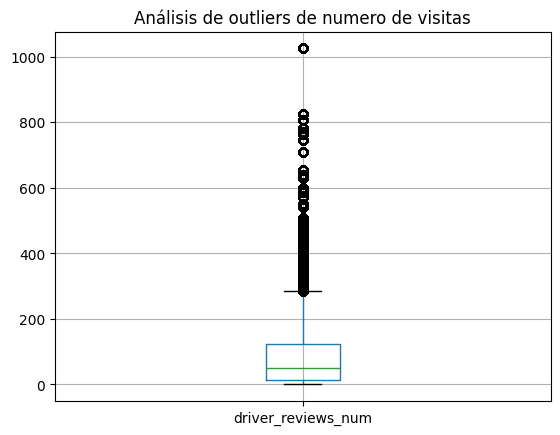

In [65]:
df[['driver_reviews_num']].boxplot()
plt.title('Análisis de outliers de numero de visitas')
plt.show()

In [66]:
umbral_alto_reviews = df['driver_reviews_num'].quantile(0.995)
df = df[df['driver_reviews_num'] <= umbral_alto_reviews]

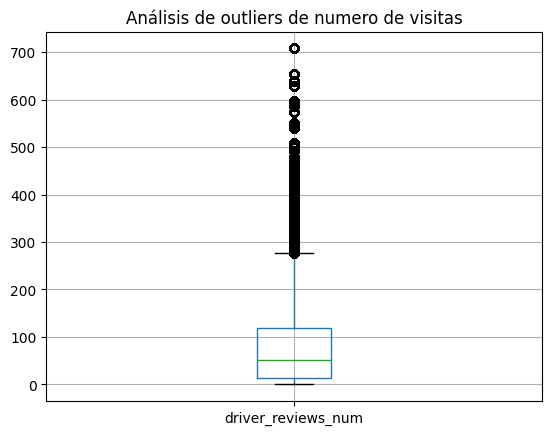

In [67]:
df[['driver_reviews_num']].boxplot()
plt.title('Análisis de outliers de numero de visitas')
plt.show()

##### En cuanto a los outliers de drivers_review_num, entendiendo que pudiera haber algún valor erróneo extremadamente lejano del global de datos se ha decidido eliminar un porcentaje diminuto de la cola superior, aunque pudiera haber algún anuncio de coche extramadamente popular, no se entiende se llegue a casos extremos.

### <u>'price'</u>

##### Nuestro tag/etiqueta.

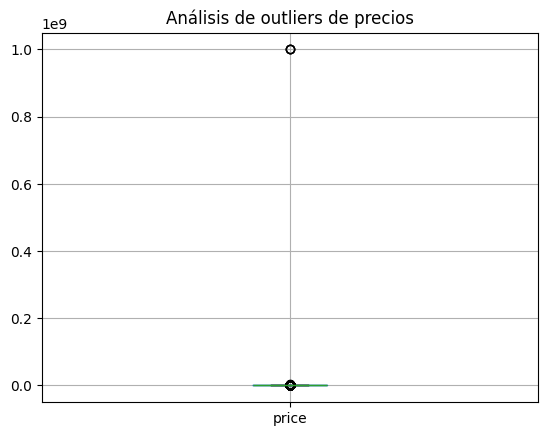

In [68]:
df[['price']].boxplot()
plt.title('Análisis de outliers de precios')
plt.show()

In [69]:
print(df['price'].max())
print(df['price'].mean())
print(df['price'].min())

1000000000
36878.647879965014
1


In [70]:
df[df['price'] == df['price'].max()]

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
108142,Chevrolet,Cobalt LT,2009,85185.0,Gasoline,0.0,1.0,1.0,"Rothrock Nissan, Chrysler, Dodge, Jeep, RAM",90,...,2.2,4.0,natural,automatic,Front-wheel Drive,Gasoline,24.0,32.0,4-5,4-5
188113,Dodge,Durango Citadel,2018,113207.0,Gasoline,0.0,1.0,1.0,"Rothrock Nissan, Chrysler, Dodge, Jeep, RAM",146,...,3.6,6.0,natural,automatic,All-wheel Drive,Gasoline,18.0,25.0,4-5,4-5
188260,Dodge,Durango Citadel,2018,113207.0,Gasoline,0.0,1.0,1.0,"Rothrock Nissan, Chrysler, Dodge, Jeep, RAM",146,...,3.6,6.0,natural,automatic,All-wheel Drive,Gasoline,18.0,25.0,4-5,4-5


In [71]:
df = df[df['price'] != df['price'].max()]

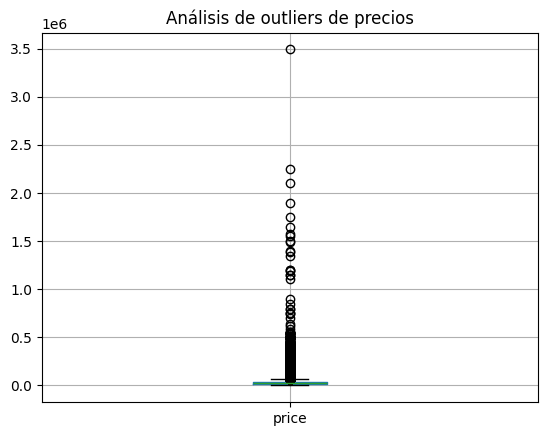

In [72]:
df[['price']].boxplot()
plt.title('Análisis de outliers de precios')
plt.show()

In [73]:
print(df['price'].max())
print(df['price'].mean())
print(df['price'].min())

3490000
32619.40766549533
1


In [74]:
df[df['price'] == df['price'].max()]

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
636956,RAM,ProMaster 3500 High Roof,2017,83000.0,Gasoline,0.0,1.0,0.0,Unknown_seller,0,...,3.6,6.0,natural,automatic,Front-wheel Drive,Gasoline,0.0,0.0,sin valoración,sin valoración


In [75]:
df = df[df['price'] != df['price'].max()]

In [76]:
df[df['price'] == df['price'].max()]

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
613085,Porsche,Carrera GT,2005,780.0,Gasoline,0.0,0.0,0.0,Hubbard Auto Center of Scottsdale,5,...,5.7,1.0,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,sin valoración,4-5


In [77]:
df = df[df['price'] != df['price'].max()]

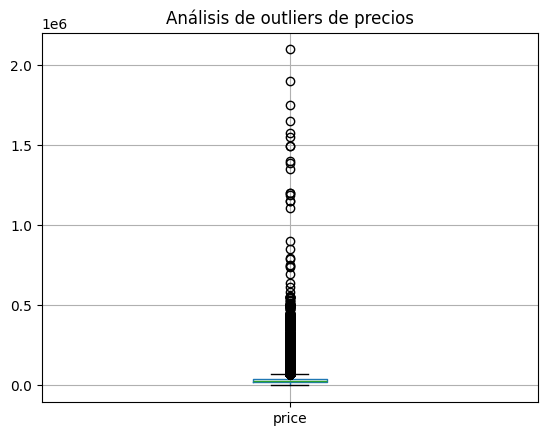

In [78]:
df[['price']].boxplot()
plt.title('Análisis de outliers de precios')
plt.show()

In [79]:
df.nlargest(20, 'price')

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
609009,Porsche,918 Spyder Base (PDK),2015,2622.0,Hybrid,0.0,0.0,1.0,Graham Rahal Performance,5,...,4.6,8.0,hybrid,automatic,All-wheel Drive,Hybrid,20.0,24.0,sin valoración,3-4
613080,Porsche,Carrera GT,2004,2361.0,Gasoline,0.0,0.0,1.0,Kearns Motor Car Co.,2,...,5.7,1.0,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,4-5,4-5
49078,BMW,750 iL,1996,121043.0,Gasoline,0.0,0.0,1.0,Celebrity Cars Las Vegas,2,...,5.4,1.0,natural,automatic,Front-wheel Drive,Gasoline,15.0,20.0,4-5,4-5
613084,Porsche,Carrera GT,2005,9610.0,Gasoline,0.0,0.0,0.0,Ilusso,5,...,5.7,1.0,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,sin valoración,4-5
213659,Ford,GT EDITION VIN 002,2018,9.0,Gasoline,0.0,1.0,1.0,HGreg.com Lux,0,...,3.5,6.0,natural,automatic,Rear-wheel Drive,Gasoline,18.0,25.0,4-5,sin valoración
613079,Porsche,Carrera GT Base (M6),2004,4376.0,Gasoline,0.0,0.0,1.0,Porsche North Houston,2,...,5.7,1.0,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,4-5,4-5
613081,Porsche,Carrera GT,2005,12996.0,Gasoline,0.0,0.0,1.0,Porsche North Olmsted,5,...,5.7,1.0,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,4-5,4-5
613083,Porsche,Carrera GT,2005,5052.0,Gasoline,0.0,1.0,1.0,ZWECK,5,...,5.7,1.0,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,sin valoración,4-5
613082,Porsche,Carrera GT Base (M6),2005,10982.0,Gasoline,0.0,0.0,1.0,Miller Motorcars,5,...,5.7,1.0,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,sin valoración,4-5
613086,Porsche,Carrera GT Base (M6),2005,11750.0,Gasoline,0.0,0.0,1.0,Merit Partners,5,...,5.7,1.0,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,4-5,4-5


In [80]:
umbral_alto = df['price'].quantile(0.999)
print(umbral_alto)

df = df[df['price'] <= umbral_alto]

238399.21400002274


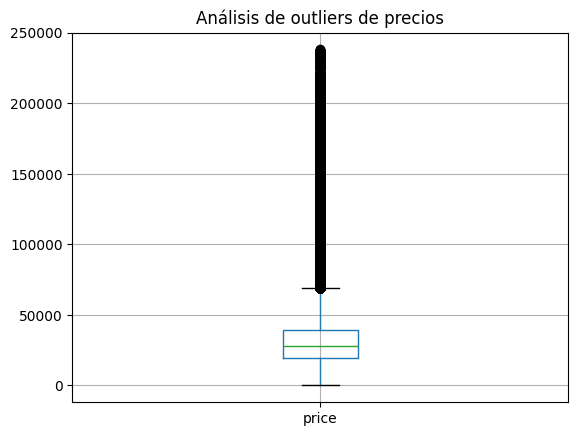

In [81]:
df[['price']].boxplot()
plt.title('Análisis de outliers de precios')
plt.show()

In [82]:
print(df['price'].max())
print(df['price'].mean())
print(df['price'].min())

238187
32305.318866202968
1


In [83]:
df[df['price'] == df['price'].min()]

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
5658,Acura,TLX V6 A-Spec,2018,49603.0,Gasoline,1.0,0.0,1.0,Luxury Auto Mall,83,...,3.5,6.0,natural,automatic,Front-wheel Drive,Gasoline,20.0,30.0,1-2,4-5
13850,Audi,A4 2.0T Premium,2014,98881.0,Gasoline,0.0,1.0,0.0,Luxury Auto Mall,59,...,2.0,4.0,turbo,automatic,Front-wheel Drive,Gasoline,24.0,32.0,1-2,4-5
660696,Subaru,Legacy 2.5i Limited,2019,31570.0,Gasoline,0.0,1.0,0.0,North Imports,57,...,2.5,4.0,turbo,automatic,All-wheel Drive,Gasoline,25.0,34.0,sin valoración,4-5
735177,Volkswagen,Jetta,2007,133964.0,Gasoline,1.0,0.0,1.0,Fred Anderson Kia,72,...,2.5,5.0,natural,manual,Front-wheel Drive,Gasoline,22.0,30.0,4-5,4-5


In [84]:
df.nsmallest(20, 'price')

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
5658,Acura,TLX V6 A-Spec,2018,49603.0,Gasoline,1.0,0.0,1.0,Luxury Auto Mall,83,...,3.5,6.0,natural,automatic,Front-wheel Drive,Gasoline,20.0,30.0,1-2,4-5
13850,Audi,A4 2.0T Premium,2014,98881.0,Gasoline,0.0,1.0,0.0,Luxury Auto Mall,59,...,2.0,4.0,turbo,automatic,Front-wheel Drive,Gasoline,24.0,32.0,1-2,4-5
660696,Subaru,Legacy 2.5i Limited,2019,31570.0,Gasoline,0.0,1.0,0.0,North Imports,57,...,2.5,4.0,turbo,automatic,All-wheel Drive,Gasoline,25.0,34.0,sin valoración,4-5
735177,Volkswagen,Jetta,2007,133964.0,Gasoline,1.0,0.0,1.0,Fred Anderson Kia,72,...,2.5,5.0,natural,manual,Front-wheel Drive,Gasoline,22.0,30.0,4-5,4-5
584638,Nissan,Versa SV,2021,45288.0,Gasoline,0.0,0.0,0.0,Lions Pre-Owned,11,...,1.6,4.0,natural,automatic,Front-wheel Drive,Gasoline,32.0,40.0,sin valoración,4-5
195371,Ford,EcoSport Titanium,2019,44077.0,Gasoline,1.0,0.0,0.0,Lions Pre-Owned,108,...,1.0,4.0,turbo,automatic,Front-wheel Drive,Gasoline,27.0,29.0,sin valoración,4-5
66049,Buick,Enclave Premium,2017,115869.0,Gasoline,1.0,0.0,1.0,Lions Pre-Owned,137,...,3.6,6.0,turbo,automatic,Front-wheel Drive,Gasoline,15.0,22.0,sin valoración,4-5
73551,Buick,Encore Essence,2019,115608.0,Gasoline,0.0,1.0,0.0,Lions Pre-Owned,183,...,1.4,4.0,unknown,automatic,Front-wheel Drive,Gasoline,0.0,0.0,sin valoración,4-5
736374,Volkswagen,Jetta S,2019,120092.0,Gasoline,0.0,1.0,0.0,Lions Pre-Owned,259,...,1.4,4.0,turbo,automatic,Front-wheel Drive,Gasoline,30.0,40.0,sin valoración,4-5
162360,Chrysler,Pacifica Touring L,2020,55240.0,Gasoline,0.0,1.0,0.0,Lions Pre-Owned,64,...,3.6,6.0,turbo,automatic,Front-wheel Drive,Gasoline,19.0,28.0,sin valoración,4-5


In [85]:
umbral_bajo = df['price'].quantile(0.001)  # percentil 0.1%
print(umbral_bajo)

df = df[df['price'] >= umbral_bajo]

3200.0


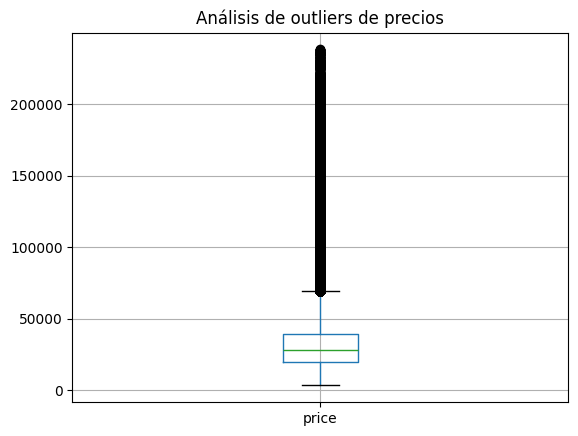

In [86]:
df[['price']].boxplot()
plt.title('Análisis de outliers de precios')
plt.show()

In [87]:
df.nsmallest(20, 'price')

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
76417,Buick,Century Custom,1999,149650.0,Gasoline,1.0,1.0,0.0,REM Motors LLC,19,...,3.1,6.0,turbo,automatic,Front-wheel Drive,Gasoline,20.0,26.0,sin valoración,4-5
78613,Cadillac,Eldorado ETC,2000,182326.0,Gasoline,0.0,0.0,0.0,Absolute Auto Solutions,12,...,4.6,8.0,turbo,automatic,Front-wheel Drive,Gasoline,17.0,25.0,1-2,4-5
127100,Chevrolet,Cavalier Base,2003,122326.0,Gasoline,0.0,0.0,0.0,Absolute Auto Solutions,45,...,2.2,4.0,turbo,automatic,Front-wheel Drive,Gasoline,25.0,30.0,1-2,4-5
159829,Chrysler,Pacifica Base,2006,146260.0,Gasoline,1.0,0.0,0.0,Dan Deery Toyota,58,...,3.5,6.0,natural,automatic,Front-wheel Drive,Gasoline,17.0,23.0,4-5,4-5
180273,Dodge,Dakota SLT,2000,146257.0,Gasoline,0.0,1.0,0.0,Unknown_seller,44,...,4.7,8.0,natural,automatic,Rear-wheel Drive,Gasoline,16.0,20.0,sin valoración,4-5
250748,Ford,Taurus SE,2010,191639.0,Gasoline,0.0,1.0,0.0,Elko Motor Company,83,...,3.5,6.0,natural,automatic,Front-wheel Drive,Gasoline,18.0,28.0,sin valoración,4-5
327342,Honda,Element EX-P,2006,0.0,Gasoline,1.0,0.0,1.0,Your Choice Autos Waukegan,46,...,2.4,4.0,turbo,automatic,Four-wheel Drive,Gasoline,21.0,24.0,4-5,4-5
347625,Hyundai,Accent GS,2013,152705.0,Gasoline,1.0,0.0,1.0,Fitzgerald Used Cars Germantown,77,...,1.6,4.0,natural,automatic,Front-wheel Drive,Gasoline,28.0,37.0,4-5,4-5
348471,Hyundai,Accent GLS,2008,148556.0,Gasoline,0.0,1.0,0.0,Unknown_seller,30,...,1.6,4.0,natural,automatic,Front-wheel Drive,Gasoline,27.0,37.0,sin valoración,3-4
383894,Jeep,Liberty Sport,2011,204500.0,Gasoline,0.0,1.0,0.0,Unknown_seller,72,...,3.7,6.0,natural,automatic,Rear-wheel Drive,Gasoline,15.0,21.0,sin valoración,4-5


##### La variable price presenta algunos valores extremadamente bajos y altos que no son representativos del mercado típico de coches de segunda mano y pueden distorsionar el análisis y los modelos.Para reducir su impacto, eliminamos solo los casos más extremos usando percentiles:

##### - Umbral inferior: percentil 0.1% de price.
##### - Umbral superior: percentil 99.9% de price.

##### Nos quedamos únicamente con las observaciones cuyo precio está entre ambos valores.

In [88]:
df

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
0,Acura,ILX Hybrid 1.5L,2013,92945.0,Gasoline,0.0,0.0,0.0,Iconic Coach,12,...,1.5,4.0,turbo,automatic,Front-wheel Drive,Gasoline,38.0,39.0,sin valoración,4-5
1,Acura,ILX Hybrid 1.5L,2013,47645.0,Hybrid,1.0,1.0,1.0,Kars Today,12,...,1.5,4.0,hybrid,automatic,Front-wheel Drive,Hybrid,38.0,39.0,sin valoración,4-5
2,Acura,ILX Hybrid 1.5L,2013,53422.0,Hybrid,0.0,1.0,1.0,Weiss Toyota of South County,12,...,1.5,4.0,hybrid,automatic,Front-wheel Drive,Hybrid,38.0,39.0,4-5,4-5
3,Acura,ILX Hybrid 1.5L,2013,117598.0,Hybrid,0.0,1.0,1.0,Apple Tree Acura,12,...,1.5,4.0,hybrid,automatic,Front-wheel Drive,Hybrid,38.0,39.0,sin valoración,4-5
4,Acura,ILX Hybrid 1.5L,2013,114865.0,Hybrid,1.0,0.0,1.0,Herb Connolly Chevrolet,12,...,1.5,4.0,hybrid,automatic,Front-wheel Drive,Hybrid,38.0,39.0,3-4,4-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,22877.0,Gasoline,0.0,1.0,0.0,Volvo Cars Danbury,2,...,2.0,4.0,turbo,automatic,All-wheel Drive,Gasoline,25.0,33.0,4-5,4-5
762087,Volvo,S60 T5,2012,72900.0,Gasoline,0.0,1.0,0.0,Unknown_seller,101,...,2.5,5.0,natural,automatic,Front-wheel Drive,Gasoline,20.0,30.0,sin valoración,4-5
762088,Volvo,S60 T5,2014,92000.0,Gasoline,0.0,0.0,1.0,Dapper Car Sales,36,...,2.5,5.0,turbo,automatic,Front-wheel Drive,Gasoline,21.0,30.0,sin valoración,4-5
762089,Volvo,S60 T5 Platinum,2013,132000.0,Gasoline,1.0,0.0,0.0,Legend Auto Sales Inc.,62,...,2.5,5.0,turbo,automatic,All-wheel Drive,Gasoline,20.0,29.0,4-5,4-5


## <u>GRÁFICOS DE DISTRIBUCIONES:</u>

### <u>Distribución del precio</u>:

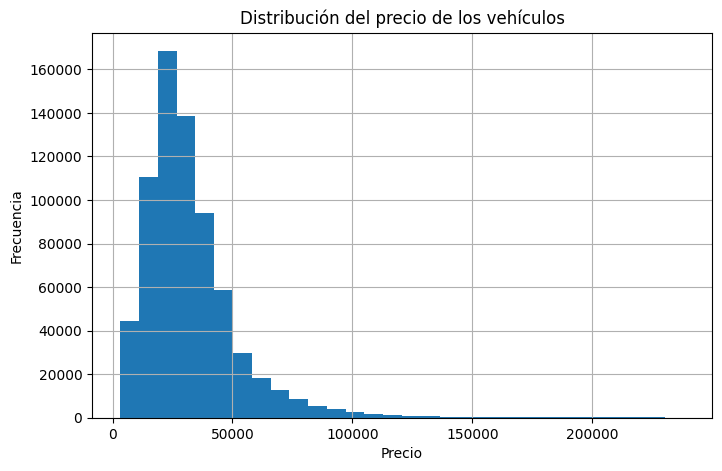

In [89]:
plt.figure(figsize=(8, 5))
df["price"].dropna().hist(bins=30)
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.title("Distribución del precio de los vehículos")
plt.show()

### <u>Precio medio por vendedor (top 10 vendedores con más coches)</u>:

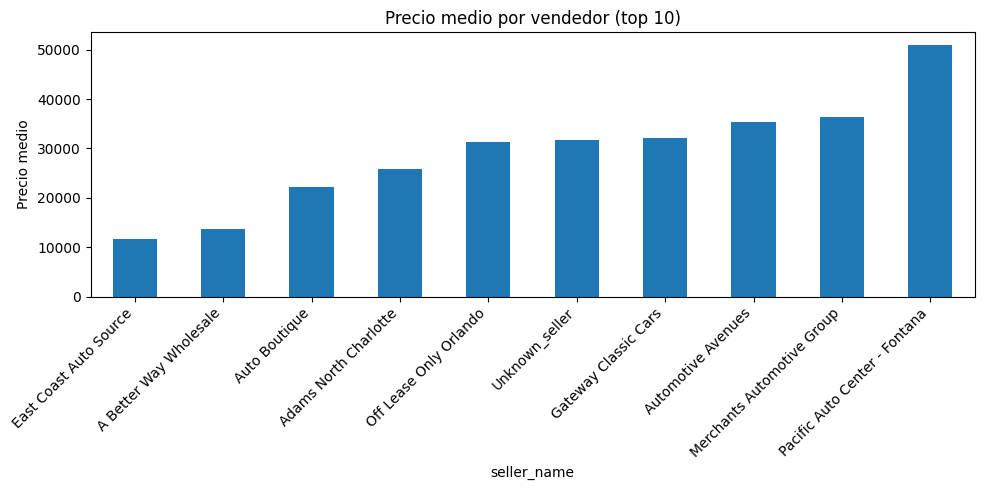

In [90]:
top_sellers = (
    df["seller_name"]
    .value_counts()
    .head(10)
    .index
)

price_by_seller = (
    df[df["seller_name"].isin(top_sellers)]
    .groupby("seller_name")["price"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 5))
price_by_seller.plot(kind="bar")
plt.ylabel("Precio medio")
plt.title("Precio medio por vendedor (top 10)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### <u>Número de reseñas de conductores</u>:

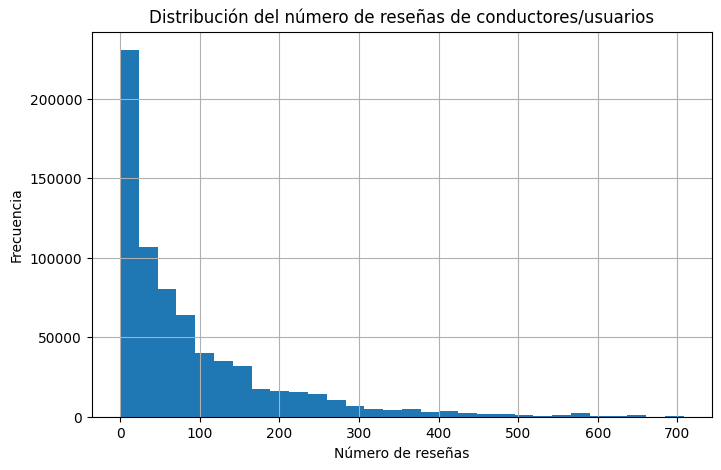

In [91]:
plt.figure(figsize=(8, 5))
df["driver_reviews_num"].dropna().hist(bins=30)
plt.xlabel("Número de reseñas")
plt.ylabel("Frecuencia")
plt.title("Distribución del número de reseñas de conductores/usuarios")
plt.show()